# Assignment-6

This notebook contains the questions to test the proficiency in `Statistics`.

### Date: 1st February, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-06-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-06-Dipika_Chopra.ipynb`.
- For numerical problems you can either solve the same using using python in the solution notebook or you can solve it on paper and upload the scan pdf copy of the solution. 
- If you are solving it on paper then name the pdf file of the scan copy of the solution as `Assignment-06-<your_name>_<your_surname>.pdf`. For example if your name is Akash Kumar then name the file as `Assignment-06-Akash_Kumar.pdf`.
- Upload the solved notebook in your github repo under the folder **Assignment-6**.
- Upload the solved notebook and the scanned pdf copy of the solutions in the google drive location: https://drive.google.com/drive/folders/1YcMNgD9h_Kdh7-Q0no3xONNctBtzqcOJ?usp=sharing 
<h3><span style="color:red"> Deadline: 22nd February, 2025 </span></h3>

<h5><span style="color:blue"> <b>Instructions:</b> Please answer all the questions. For problems requiring numerical solutions, you are encouraged to write code in Python to compute the results. Show your steps and explain your reasoning. </span></h5>

In [31]:
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis,pearsonr,chi2_contingency, chi2
import pandas as pd


### Problem-1

A startup company with 20 employees recorded their annual salaries (in INR Lakhs):
`[6.5, 7.2, 8.0, 6.8, 9.5, 7.0, 15.0, 7.5, 8.2, 6.9, 7.8, 10.5, 7.1, 8.5, 6.7, 7.3, 7.9, 9.0, 8.8, 7.6]`

(a) Calculate the mean, median, and mode of the salaries.

(b) Determine the range, variance, and standard deviation of the salaries.

(c) Calculate the Interquartile Range (IQR). What does the IQR tell you about the salary distribution?

(d) Construct a box plot for the salaries. Identify any potential outliers.


Mean: 8.19
Median: 7.70
Mode: 6.50
Range: 8.50
Variance: 3.62
Std Dev: 1.90
IQR: 1.50
Outliers: [15.0]


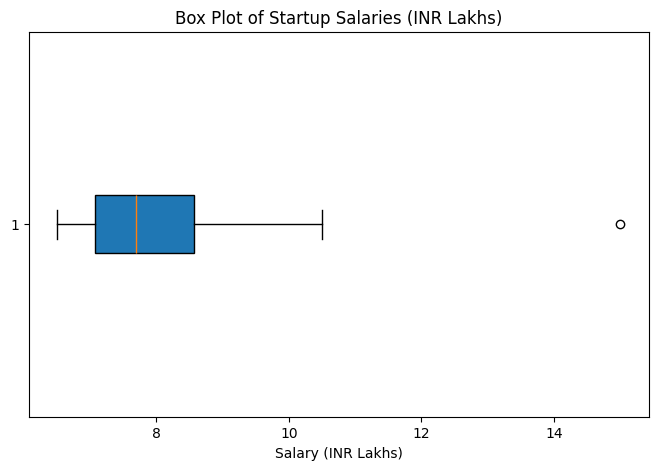

In [16]:
salaries = [6.5, 7.2, 8.0, 6.8, 9.5, 7.0, 15.0, 7.5, 8.2, 6.9, 
            7.8, 10.5, 7.1, 8.5, 6.7, 7.3, 7.9, 9.0, 8.8, 7.6]

# (a) Central Tendency
mean = np.mean(salaries)
median = np.median(salaries)
mode_res = stats.mode(salaries, keepdims=True)
mode = mode_res.mode[0]

# (b) Dispersion
salary_range = np.max(salaries) - np.min(salaries)
variance = np.var(salaries, ddof=1) # Using Sample Variance
std_dev = np.std(salaries, ddof=1)

# (c) IQR
q1 = np.percentile(salaries, 25)
q3 = np.percentile(salaries, 75)
iqr = q3 - q1

# (d) Outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = [x for x in salaries if x < lower_bound or x > upper_bound]

# Print Results
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode: {mode:.2f}")
print(f"Range: {salary_range:.2f}")
print(f"Variance: {variance:.2f}")
print(f"Std Dev: {std_dev:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Outliers: {outliers}")

# Plotting
plt.figure(figsize=(8, 5))
plt.boxplot(salaries, vert=False, patch_artist=True)
plt.title("Box Plot of Startup Salaries (INR Lakhs)")
plt.xlabel("Salary (INR Lakhs)")
plt.show()

### Problem-2

A tech company conducted a customer satisfaction survey, rating their latest product on a scale of 1 to 10 (10 being highly satisfied). The scores from 30 randomly selected customers are:
[7, 8, 9, 6, 7, 8, 10, 5, 7, 8, 9, 7, 6, 8, 7, 9, 10, 6, 7, 8, 5, 9, 8, 7, 6, 7, 8, 9, 7, 8]

(a) Create a frequency distribution table for these scores.

(b) Plot a histogram of the customer satisfaction scores. Describe the shape of the distribution (e.g., symmetric, skewed).

(c) Calculate the Pearson's (first and second) coefficients of skewness for this data. Interpret the values.

(d) Calculate the excess kurtosis for this data using sample kurtosis formula. What does the kurtosis value suggest about the tails of the distribution?

Frequency Table:
 Score  Frequency
     5          2
     6          4
     7          9
     8          8
     9          5
    10          2

Mean: 7.53, Median: 7.50, Mode: 7
Pearson's 1st Coeff: 0.4084
Pearson's 2nd Coeff: 0.0766
Excess Kurtosis: -0.3811


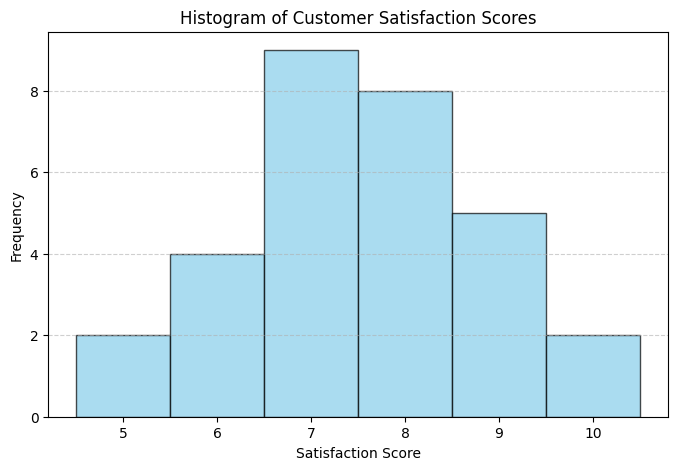

In [18]:
scores = [7, 8, 9, 6, 7, 8, 10, 5, 7, 8, 9, 7, 6, 8, 7, 9, 10, 6, 7, 8, 5, 9, 8, 7, 6, 7, 8, 9, 7, 8]

# (a) Frequency Distribution Table
df = pd.Series(scores).value_counts().sort_index().reset_index()
df.columns = ['Score', 'Frequency']

# Calculations for Skewness and Kurtosis
mean = np.mean(scores)
median = np.median(scores)
std_dev = np.std(scores, ddof=1)
mode = df.loc[df['Frequency'].idxmax(), 'Score']

# (c) Pearson's Coefficients
pearson_first = (mean - mode) / std_dev
pearson_second = 3 * (mean - median) / std_dev

# (d) Excess Kurtosis (Fisher’s definition: normal = 0)
excess_kurt = kurtosis(scores, fisher=True, bias=False)

# Print Results
print("Frequency Table:")
print(df.to_string(index=False))
print(f"\nMean: {mean:.2f}, Median: {median:.2f}, Mode: {mode}")
print(f"Pearson's 1st Coeff: {pearson_first:.4f}")
print(f"Pearson's 2nd Coeff: {pearson_second:.4f}")
print(f"Excess Kurtosis: {excess_kurt:.4f}")

# (b) Histogram
plt.figure(figsize=(8, 5))
plt.hist(scores, bins=range(5, 12), align='left', color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Histogram of Customer Satisfaction Scores")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.xticks(range(5, 11))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Problem-3

A marketing team wants to understand the relationship between their monthly advertising expenditure (in INR Lakhs) and corresponding sales revenue (in INR Lakhs) over the last 10 months.

| Month | Advertising Spend (X) | Sales Revenue (Y) |
|-------|-----------------------|-------------------|
|     1 |                     5 |                52 |
|     2 |                     7 |                65 |
|     3 |                     6 |                60 |
|     4 |                     8 |                70 |
|     5 |                     5 |                55 |
|     6 |                     9 |                75 |
|     7 |                     7 |                68 |
|     8 |                    10 |                80 |
|     9 |                     6 |                58 |
|    10 |                     8 |                72 |


(a) Calculate the covariance between advertising spend and sales revenue.

(b) Plot Sales Revenue vs Advertising spent.

(c) Calculate the Pearson correlation coefficient between advertising spend and sales revenue.

(d) Interpret the meaning of both the covariance and the correlation coefficient in the context of this data.

Covariance: 14.94
Pearson Correlation Coefficient (r): 0.9852


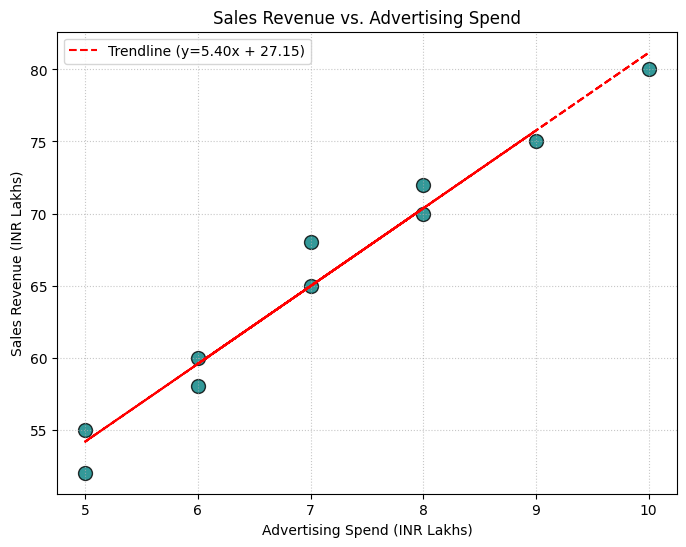

In [21]:

# Dataset
X = np.array([5, 7, 6, 8, 5, 9, 7, 10, 6, 8])  # Advertising Spend
Y = np.array([52, 65, 60, 70, 55, 75, 68, 80, 58, 72])  # Sales Revenue

# (a) Covariance
# np.cov returns a matrix; [0, 1] is the covariance between X and Y
covariance_matrix = np.cov(X, Y)
covariance = covariance_matrix[0, 1]

# (c) Pearson Correlation Coefficient
correlation, _ = pearsonr(X, Y)

# Print Results
print(f"Covariance: {covariance:.2f}")
print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

# (b) Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='teal', s=100, edgecolors='black', alpha=0.8)

# Adding a trendline
m, b = np.polyfit(X, Y, 1)
plt.plot(X, m*X + b, color='red', linestyle='--', label=f'Trendline (y={m:.2f}x + {b:.2f})')

plt.title("Sales Revenue vs. Advertising Spend")
plt.xlabel("Advertising Spend (INR Lakhs)")
plt.ylabel("Sales Revenue (INR Lakhs)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### Problem-4

A traffic department claims that the average daily commute time for residents in a certain city is 45 minutes. A researcher believes this claim is too low and collects data from a random sample of 100 residents. The sample mean commute time is 48 minutes with a standard deviation of 12 minutes.

(a) Formulate the null and alternative hypotheses for this scenario.

(b) Construct a 95% confidence interval for the true average daily commute time.

(c) Based on the confidence interval, what can you conclude about the traffic department's claim?

In [22]:
null_mean = 45
sample_mean = 48
sample_std = 12
n = 100
confidence_level = 0.95

# 1. Standard Error (SE)
standard_error = sample_std / np.sqrt(n)

# 2. Critical Value (Z) for 95% Confidence
z_critical = stats.norm.ppf((1 + confidence_level) / 2)

# 3. Margin of Error
margin_of_error = z_critical * standard_error

# 4. Confidence Interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# Print Results
print(f"Sample Mean: {sample_mean}")
print(f"Standard Error: {standard_error:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

# 5. One-tailed p-value for the hypothesis test
z_score = (sample_mean - null_mean) / standard_error
p_value = 1 - stats.norm.cdf(z_score)
print(f"Z-score: {z_score:.2f}")
print(f"P-value: {p_value:.4f}")

Sample Mean: 48
Standard Error: 1.20
95% Confidence Interval: (45.65, 50.35)
Z-score: 2.50
P-value: 0.0062


### Problem-5

A manufacturing company wants to estimate the average number of units produced per hour by a new machine. They take 36 random observations and find the sample mean to be 150 units with a sample standard deviation of 15 units.

(a) What is the point estimate for the true average number of units produced per hour?

(b) Construct a 99% confidence interval for the true average number of units produced per hour.

(c) If the company wants to be 99% confident that their estimate is within 3 units of the true mean, what sample size would they need (assuming the same standard deviation)?

In [23]:
sample_mean = 150
sample_std = 15
n = 36
confidence_level = 0.99

# (a) Point Estimate
point_estimate = sample_mean

# (b) 99% Confidence Interval
# Since n > 30, we use the Z-critical value
z_critical = stats.norm.ppf((1 + confidence_level) / 2)
standard_error = sample_std / np.sqrt(n)
margin_of_error = z_critical * standard_error

ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# (c) Sample Size for Margin of Error (E) = 3
target_e = 3
required_n = ((z_critical * sample_std) / target_e)**2

print(f"Point Estimate: {point_estimate}")
print(f"Z-critical Value: {z_critical:.3f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"Required Sample Size: {np.ceil(required_n)}")

Point Estimate: 150
Z-critical Value: 2.576
95% CI: (143.56, 156.44)
Required Sample Size: 166.0


### Problem-6

A website designer believes that a new website redesign will increase the average time users spend on the site. Before the redesign, the average time spent was 3.5 minutes. After the redesign, a random sample of 50 users showed an average time of 3.8 minutes with a standard deviation of 1.0 minute.

(a) Perform a one-sided hypothesis test at a 0.05 significance level to determine if the redesign significantly increased the average time spent.

(b) State your null and alternative hypotheses, calculate the test statistic, and determine the p-value.

(c) What is your conclusion regarding the website redesign's impact?

In [ ]:
"""
Null Hypothesis (H0): (The redesign has no effect; average time remains 3.5 minutes).
Alternative Hypothesis (H1): (The redesign increased the average time spent)."""
mu_null = 3.5
x_bar = 3.8
s = 1.0
n = 50
alpha = 0.05

# Calculate Test Statistic (Z-score)
# Formula: Z = (x_bar - mu) / (s / sqrt(n))
standard_error = s / np.sqrt(n)
z_stat = (x_bar - mu_null) / standard_error

# Calculate P-value (One-sided test)
p_value = 1 - stats.norm.cdf(z_stat)

# Determine Critical Value
z_critical = stats.norm.ppf(1 - alpha)

print(f"Test Statistic (Z): {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Critical Z-value: {z_critical:.4f}")

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis")
else:
    print("Decision: Fail to Reject the Null Hypothesis")

Test Statistic (Z): 2.1213
P-value: 0.0169
Critical Z-value: 1.6449
Decision: Reject the Null Hypothesis


### Problem-7

A company implemented a new training program to improve employee productivity. To assess its effectiveness, 15 employees' productivity scores were recorded before and after the training program. The scores are as follows:

| Employee | Before Training | After Training |
|----------|-----------------|----------------|
|        1 |              65 |             70 |
|        2 |              70 |             72 |
|        3 |              60 |             68 |
|        4 |              75 |             73 |
|        5 |              80 |             85 |
|        6 |              68 |             70 |
|        7 |              72 |             75 |
|        8 |              62 |             65 |
|        9 |              78 |             80 |
|       10 |              70 |             72 |
|       11 |              66 |             69 |
|       12 |              73 |             76 |
|       13 |              64 |             67 |
|       14 |              71 |             74 |
|       15 |              69 |             71 |

(a) State the null and alternative hypotheses to test if the training program significantly improved productivity.

(b) Conduct a paired samples t-test at a 0.05 significance level. Calculate the test statistic and the p-value.

(c) Based on your analysis, did the training program effectively improve employee productivity?

In [27]:
"""Null Hypothesis (H0):There is no significant difference in productivity scores before and after the training.
Alternative Hypothesis (H1): The training program significantly improved productivity scores """

before = np.array([65, 70, 60, 75, 80, 68, 72, 62, 78, 70, 66, 73, 64, 71, 69])
after  = np.array([70, 72, 68, 73, 85, 70, 75, 65, 80, 72, 69, 76, 67, 74, 71])

# Calculate differences
differences = after - before

# Perform Paired Samples T-Test
# 'greater' specifies the one-sided alternative hypothesis (after > before)
t_stat, p_value = stats.ttest_rel(after, before, alternative='greater')

# Manual calculation for transparency
mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)
n = len(differences)
se_diff = std_diff / np.sqrt(n)

print(f"Mean Difference: {mean_diff:.2f}")
print(f"Standard Deviation of Diff: {std_diff:.2f}")
print(f"Test Statistic (t): {t_stat:.4f}")
print(f"P-value: {p_value:.8f}")

# Conclusion logic
alpha = 0.05
if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis")

Mean Difference: 2.93
Standard Deviation of Diff: 2.12
Test Statistic (t): 5.3583
P-value: 0.00005046

Decision: Reject the Null Hypothesis


### Problem-8

A battery manufacturer claims that their new 'ProLife' battery lasts longer than their existing 'Standard' battery. A consumer watchdog organization tests 40 'ProLife' batteries and 50 'Standard' batteries. The results are:

ProLife: Sample mean life = 120 hours, Sample standard deviation = 10 hours

Standard: Sample mean life = 115 hours, Sample standard deviation = 12 hours

(a) State the null and alternative hypotheses for testing the manufacturer's claim.

(b) Perform a t-test for two independent means at a 0.02 significance level.

(c) What is your conclusion regarding the manufacturer's claim about the 'ProLife' battery?

In [28]:
n1, mean1, std1 = 40, 120, 10  # ProLife
n2, mean2, std2 = 50, 115, 12  # Standard
alpha = 0.02

# 1. Calculate the t-statistic (Welch's T-test formula)
# t = (mean1 - mean2) / sqrt((std1^2 / n1) + (std2^2 / n2))
se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
t_stat = (mean1 - mean2) / se

# 2. Degrees of Freedom (Satterthwaite Approximation)
df_numerator = (std1**2/n1 + std2**2/n2)**2
df_denominator = (std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1)
df = df_numerator / df_denominator

# 3. P-value (One-tailed)
p_value = 1 - stats.t.cdf(t_stat, df)

print(f"Test Statistic (t): {t_stat:.4f}")
print(f"Degrees of Freedom: {df:.2f}")
print(f"P-value: {p_value:.4f}")

# Conclusion Logic
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis")
else:
    print("Decision: Fail to Reject the Null Hypothesis")

Test Statistic (t): 2.1557
Degrees of Freedom: 87.84
P-value: 0.0169
Decision: Reject the Null Hypothesis


### Problem-9

A popular restaurant chain claims that the average waiting time for a table on weekends is no more than 20 minutes. A local food critic believes it's longer. They record the waiting times (in minutes) for 30 randomly selected tables on various weekends:

`[22, 25, 18, 30, 28, 20, 23, 26, 19, 32, 21, 24, 27, 29, 20, 25, 23, 17, 31, 26, 22, 28, 20, 24, 27, 29, 21, 23, 25, 26]`

(a) Calculate the sample mean and sample standard deviation of the waiting times.

(b) Conduct a one-sided t-test at a 0.01 significance level to assess the food critic's belief.

(c) State your null and alternative hypotheses, calculate the test statistic, and determine the critical value.

(d) Based on your findings, what can you tell the food critic?

In [29]:
wait_times = [22, 25, 18, 30, 28, 20, 23, 26, 19, 32, 21, 24, 27, 29, 20, 
              25, 23, 17, 31, 26, 22, 28, 20, 24, 27, 29, 21, 23, 25, 26]

# (a) Descriptive Statistics
n = len(wait_times)
mean = np.mean(wait_times)
std_dev = np.std(wait_times, ddof=1) # Sample standard deviation

# (b) & (c) Hypothesis Testing
mu_0 = 20
alpha = 0.01

# Calculate t-statistic: (x_bar - mu) / (s / sqrt(n))
t_stat = (mean - mu_0) / (std_dev / np.sqrt(n))

# Degrees of freedom
df = n - 1

# Critical value for one-sided test (upper tail)
t_critical = stats.t.ppf(1 - alpha, df)

# P-value
p_value = 1 - stats.t.cdf(t_stat, df)

print(f"Sample Mean: {mean:.2f}")
print(f"Sample Std Dev: {std_dev:.2f}")
print(f"Test Statistic (t): {t_stat:.4f}")
print(f"Critical Value (t_crit): {t_critical:.4f}")
print(f"P-value: {p_value:.8f}")

Sample Mean: 24.37
Sample Std Dev: 3.93
Test Statistic (t): 6.0922
Critical Value (t_crit): 2.4620
P-value: 0.00000062


### Problem-10

A software company is launching a new application and offers three different subscription tiers (Basic, Premium, Elite), each with varying features. Before the full launch, they conduct a pilot study to see if there's an association between a customer's age group and their preferred subscription tier. They surveyed 300 randomly selected potential customers and recorded their age group and preferred tier:

| Age Group   | Basic | Premium | Elite | Total |
|-------------|-------|---------|-------|-------|
| 18-29 years |    45 |      60 | 15    | 120   |
| 30-49 years |    30 |      50 | 20    | 100   |
|   50+ years |    25 |      40 | 15    | 80    |
|       Total |   100 |     150 | 50    | 300   |


(a) State the null and alternative hypotheses for the test of independence in this context.

(b) Calculate the expected frequencies for each cell in the table, assuming the null hypothesis is true. Show your calculations clearly.

(c) Calculate the chi-square test statistic.

(d) Using a significance level of α=0.05, determine the critical value for this test.

(e) What is your conclusion? Is there a significant association between a customer's age group and their preferred subscription tier? Justify your answer based on your calculated chi-square statistic and the critical value.

In [33]:
observed = np.array([
    [45, 60, 15],
    [30, 50, 20],
    [25, 40, 15]
])

# Perform Chi-Square Test
chi2_stat, p_val, dof, expected = chi2_contingency(observed)

# Critical Value for alpha = 0.05
alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)

print(f"Chi-Square Statistic: {chi2_stat:.3f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_val:.4f}")
print(f"Critical Value: {critical_value:.3f}")
print("\nExpected Frequencies:")
print(expected)

Chi-Square Statistic: 3.188
Degrees of Freedom: 4
P-value: 0.5270
Critical Value: 9.488

Expected Frequencies:
[[40.         60.         20.        ]
 [33.33333333 50.         16.66666667]
 [26.66666667 40.         13.33333333]]


### Bonus Problem

An e-commerce company is testing two different designs for its product pages (Design A and Design B) to see if one leads to significantly higher conversion rates (percentage of visitors who make a purchase). They randomly assigned 50,000 website visitors to see Design A and another 50,000 visitors to see Design B over a two-week period. At the end of the period, they collected data on the conversion rates. Due to data collection specifics, they have daily average conversion rates for 30 randomly selected days for each design, rather than individual visitor data.

Here are the summary statistics for the daily average conversion rates (in percentage points):

* Design A (Sample 1):

    - Number of days ($n_A$) = 30
    - Mean Daily Conversion Rate ($\bar{x}_A$) = 2.85%
    - Sample Standard Deviation ($s_A$) = 0.45%

* Design B (Sample 2):

    - Number of days ($n_B$) = 30
    - Mean Daily Conversion Rate ($\bar{x}_B$) = 3.05%
    - Sample Standard Deviation ($s_B$) = 0.60%

The company is concerned that the variability in conversion rates might differ between the two designs due to different aesthetic elements or backend processes.

(a) State the null and alternative hypotheses to test if there is a significant difference in the average daily conversion rates between Design A and Design B. (Consider a two-tailed test, as they are looking for any significant difference).

(b) Before performing the t-test, you need to decide whether to assume equal or unequal population variances. For the purpose of this problem, assume that a prior test suggests equal population variances.

(c) Calculate the appropriate test statistic (t-value) for comparing the two independent means, assuming equal population variances. Show all steps of your calculation.

(d) Determine the degrees of freedom for this test. 

(e) Using a significance level of α=0.05, determine the critical value(s) for your test.

(f) Based on your calculated test statistic and the critical value(s), what is your conclusion? Is there a statistically significant difference in the average daily conversion rates between Design A and Design B?

(g) Construct a 95% confidence interval for the difference between the true mean daily conversion rates $(μ_B - μ_A)$. Interpret this interval in the context of the problem.

(h) Show all the steps when a prior test suggests unequal population variances.